## Part 1 - NBA Player Comparision

In [1]:
# As usual, we begin by importing the packages we will need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# The data consists of the shot log for the NBA season 2016/17

shot = pd.read_csv("Assignment Data/Week 3/NBA shotlog_16_17.csv")
pd.set_option('display.max_columns', 100)
print(shot.columns.tolist())
shot.describe()

['self_previous_shot', 'player_position', 'home_game', 'location_x', 'opponent_previous_shot', 'home_team', 'shot_type', 'points', 'away_team', 'location_y', 'time', 'date', 'shoot_player', 'time_from_last_shot', 'quarter', 'current_shot_outcome']


,location_x,points,location_y,time_from_last_shot,quarter
count,209675.000000,210072.000000,209675.00000,200072.000000,210072.000000
mean,468.524507,2.316130,249.44723,33.279489,2.480383
std,345.063654,0.464965,111.02320,19.797357,1.136841
min,0.000000,2.000000,0.00000,0.000000,1.000000
25%,94.000000,2.000000,197.00000,22.000000,1.000000
50%,342.000000,2.000000,250.00000,31.000000,2.000000
75%,843.000000,3.000000,303.00000,41.000000,3.000000
max,933.000000,3.000000,500.00000,255.000000,8.000000


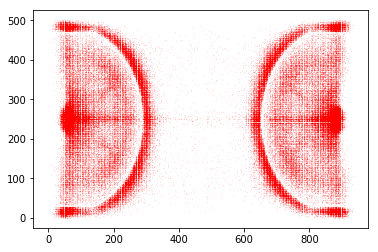

In [4]:
# A simple plot of coordinates

x = shot['location_x']
y = shot['location_y']
plt.scatter(x,y, s=.005,c='r', marker= '.')

Text(0.5, 1.0, 'Shots')

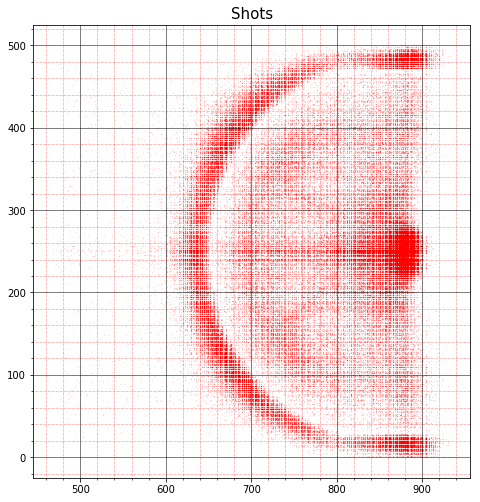

In [6]:
shot['halfcourt_x'] = np.where(shot['location_x'] < 933/2, 933 - shot['location_x'],shot['location_x'])
shot['halfcourt_y'] = np.where(shot['location_x'] < 933/2, 500 - shot['location_y'],shot['location_y'])

# all shots shown on a half court

hx = shot['halfcourt_x']
hy = shot['halfcourt_y']
plt.figure(figsize=(94/12,50/6))
plt.scatter(hx,hy, s=.01,c='r', marker= '.')
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth='.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='red')
plt.title("Shots", fontsize = 15)


In [7]:
# Comparing players

# We use a pivot table here to list players by shots

playersn = shot.groupby('shoot_player')['current_shot_outcome'].describe().reset_index()
playersn.sort_values(by = 'count', ascending = False)

,shoot_player,count,unique,top,freq
402,Russell Westbrook,1940,3,MISSED,1026
25,Andrew Wiggins,1568,3,MISSED,760
106,DeMar DeRozan,1545,3,MISSED,731
193,James Harden,1532,3,MISSED,772
28,Anthony Davis,1525,3,SCORED,770
88,Damian Lillard,1489,3,MISSED,728
257,Karl-Anthony Towns,1479,3,SCORED,802
175,Isaiah Thomas,1473,3,SCORED,682
262,Kemba Walker,1451,3,MISSED,695
424,Stephen Curry,1444,3,MISSED,713


## Westbrook - Durant Comparision

In [9]:
westbrook = shot[shot['shoot_player']=='Russell Westbrook']
westbrook

,self_previous_shot,player_position,home_game,location_x,opponent_previous_shot,home_team,shot_type,points,away_team,location_y,time,date,shoot_player,time_from_last_shot,quarter,current_shot_outcome,halfcourt_x,halfcourt_y
140311,NaN,PG,No,853.0,NaN,PHI,Jump Shot,2,OKL,76.0,0:17,10/26/2016,Russell Westbrook,NaN,1,MISSED,853.0,76.0
140314,MISSED,PG,No,802.0,SCORED,PHI,Pullup Jump Shot,2,OKL,367.0,1:51,10/26/2016,Russell Westbrook,50.0,1,SCORED,802.0,367.0
140319,BLOCKED,PG,No,853.0,SCORED,PHI,Jump Shot,2,OKL,308.0,3:59,10/26/2016,Russell Westbrook,27.0,1,BLOCKED,853.0,308.0
140321,SCORED,PG,No,809.0,SCORED,PHI,Pullup Jump Shot,2,OKL,433.0,4:54,10/26/2016,Russell Westbrook,34.0,1,MISSED,809.0,433.0
140322,MISSED,PG,No,895.0,SCORED,PHI,Driving Finger Roll Layup,2,OKL,270.0,5:44,10/26/2016,Russell Westbrook,50.0,1,SCORED,895.0,270.0
140324,MISSED,PG,No,882.0,BLOCKED,PHI,Running Layup,2,OKL,241.0,7:08,10/26/2016,Russell Westbrook,45.0,1,SCORED,882.0,241.0
140326,SCORED,PG,No,886.0,MISSED,PHI,Turnaround Jump Shot,2,OKL,401.0,7:59,10/26/2016,Russell Westbrook,28.0,1,SCORED,886.0,401.0
140349,MISSED,PG,No,819.0,SCORED,PHI,Step Back Jump Shot,2,OKL,138.0,7:26,10/26/2016,Russell Westbrook,23.0,2,SCORED,819.0,138.0
140353,SCORED,PG,No,889.0,SCORED,PHI,Jump Shot,2,OKL,434.0,9:38,10/26/2016,Russell Westbrook,48.0,2,SCORED,889.0,434.0
140354,SCORED,PG,No,763.0,MISSED,PHI,Step Back Jump Shot,2,OKL,136.0,10:07,10/26/2016,Russell Westbrook,29.0,2,MISSED,763.0,136.0


Text(0.5, 1.0, 'Westbrook')

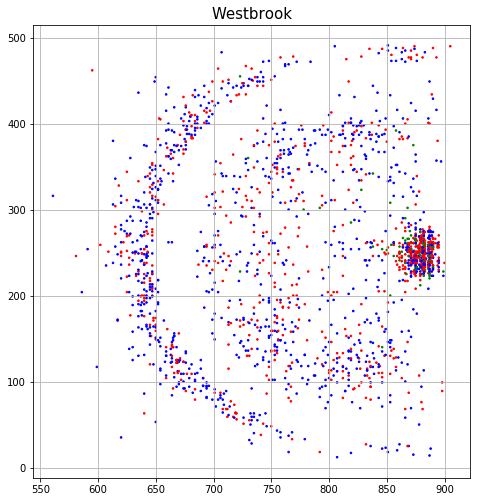

In [11]:
hxW = westbrook['halfcourt_x']
hyW = westbrook['halfcourt_y']
colors = np.where(westbrook['current_shot_outcome']=='SCORED','r',np.where(westbrook['current_shot_outcome']=='MISSED','b','g'))
plt.figure(figsize=(94/12,50/6))
plt.scatter(hxW,hyW, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("Westbrook", fontsize = 15)

Text(0.5, 1.0, 'Durant')

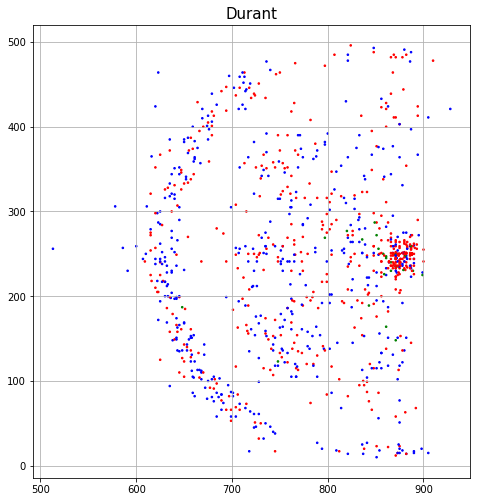

In [12]:
durant = shot[shot['shoot_player']=='Kevin Durant']
hxD = durant['halfcourt_x']
hyD = durant['halfcourt_y']
colors = np.where(durant['current_shot_outcome']=='SCORED','r',np.where(durant['current_shot_outcome']=='MISSED','b','g'))
plt.figure(figsize=(94/12,50/6))
plt.scatter(hxD,hyD, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("Durant", fontsize = 15)


(0, 500)

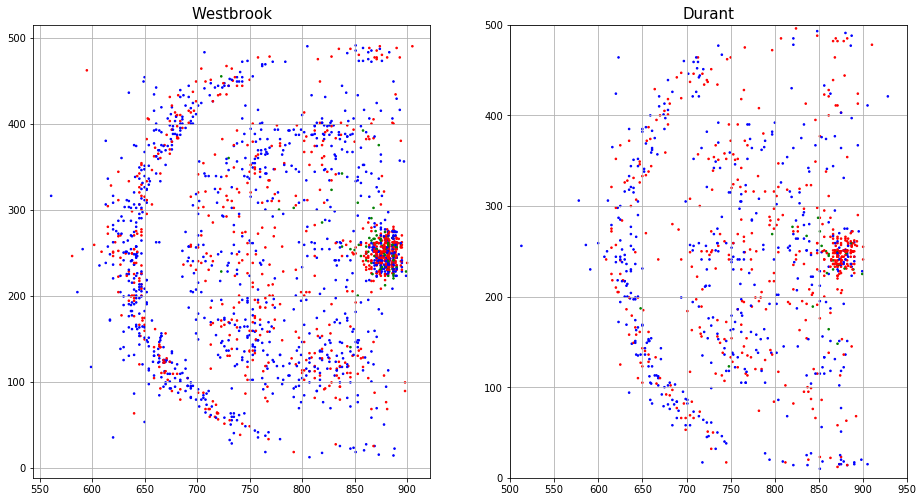

In [16]:
f = plt.figure(figsize=(94/6,50/6))
ax = f.add_subplot(121)
colors = np.where(westbrook['current_shot_outcome']=='SCORED','r',np.where(westbrook['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxW,hyW, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("Westbrook", fontsize = 15)
ax = f.add_subplot(122)
colors = np.where(durant['current_shot_outcome']=='SCORED','r',np.where(durant['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxD,hyD, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("Durant", fontsize = 15)
plt.xlim(500,950)
plt.ylim(0,500)

## Jordan - Howard Comparision

(0, 500)

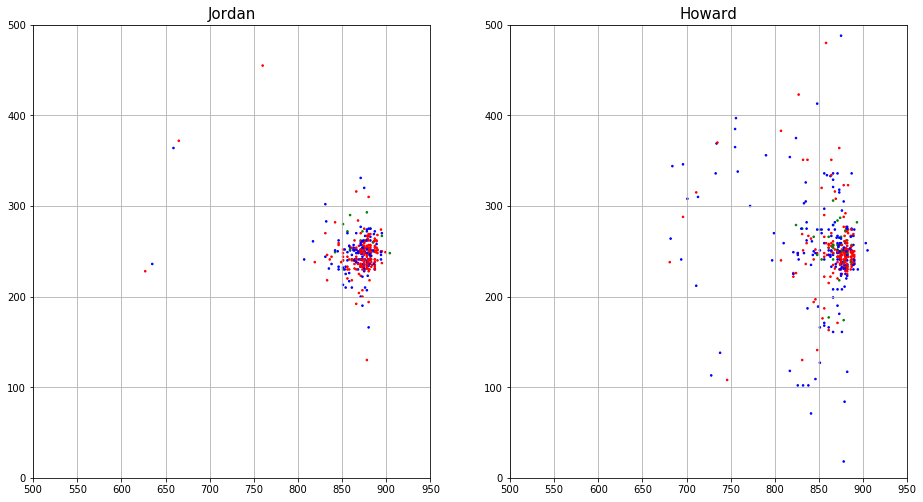

In [18]:
jordan = shot[shot['shoot_player']=='DeAndre Jordan']
hxJ = jordan['halfcourt_x']
hyJ = jordan['halfcourt_y']
howard = shot[shot['shoot_player']=='Dwight Howard']
hxH = howard['halfcourt_x']
hyH = howard['halfcourt_y']
f = plt.figure(figsize=(94/6,50/6))
ax = f.add_subplot(121)
colors = np.where(jordan['current_shot_outcome']=='SCORED','r',np.where(jordan['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxJ,hyJ, s=10, c= colors, marker= '.')
plt.grid(True)
plt.xlim(500,950)
plt.ylim(0,500)
plt.title("Jordan", fontsize = 15)
ax = f.add_subplot(122)
colors = np.where(howard['current_shot_outcome']=='SCORED','r',np.where(howard['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxH,hyH, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("Howard", fontsize = 15)
plt.xlim(500,950)
plt.ylim(0,500)

## Lopez - Lopez Comparision

In [ ]:
brook = shot[shot['shoot_player']=='Brook Lopez']
hxJ = brook['halfcourt_x']
hyJ = brook['halfcourt_y']
brian = shot[shot['shoot_player']=='Robin Lopez']
hxH = brian['halfcourt_x']
hyH = brian['halfcourt_y']
f = plt.figure(figsize=(94/6,50/6))
ax = f.add_subplot(121)
colors = np.where(brook['current_shot_outcome']=='SCORED','r',np.where(brook['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxJ,hyJ, s=10, c= colors, marker= '.')
plt.grid(True)
plt.xlim(500,950)
plt.ylim(0,500)
plt.title("brook", fontsize = 15)
ax = f.add_subplot(122)
colors = np.where(brian['current_shot_outcome']=='SCORED','r',np.where(brian['current_shot_outcome']=='MISSED','b','g'))
ax = plt.scatter(hxH,hyH, s=10, c= colors, marker= '.')
plt.grid(True)
plt.title("brian", fontsize = 15)
plt.xlim(500,950)
plt.ylim(0,500)

(0, 500)